In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from app.data_providers import test_train_dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.calibration import CalibrationDisplay

from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import classification_report

from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier

import joblib

from copy import deepcopy

pd.set_option('display.max_columns', None)

# Goal for this test:
- Try to train a model that is more balanced per shot type
- Find a model that is not just saying all free throws are hits, all jump shots are misses
## Steps:
1. Apply sample weights, based on the MAIN_ACTION_TYPE frequency
2. Train one model per action type

## Model architecture:
- Same as before, just added free throw as seperate MAIN_ACTION_TYPE instead of "Other"

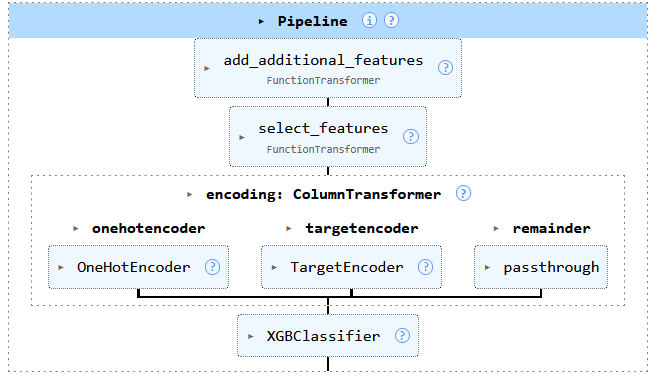

- Add additional features:
    - year
    - opponent team abbreviation
- Select features:
    - ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot',
    'IsOvertime',
    'is_playoffs']
- Encoding:
    - OneHotEncoding:
        ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
    - TargetEncoding:
        ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']
- Model:
    - XGboost classifier  

# Sample weights
- The weight of a sample is based the inverse frequency of MAIN_ACTION_TYPE

## Data and model preparation

In [3]:
data = test_train_dataset()

X_train = data['train'].drop('SHOT_MADE_FLAG', axis=1)
y_train = data['train']['SHOT_MADE_FLAG']

X_test = data['test'].drop('SHOT_MADE_FLAG', axis=1)
y_test = data['test']['SHOT_MADE_FLAG']

Repo card metadata block was not found. Setting CardData to empty.


In [4]:
# Add free throw as main action type
def add_freethrow_actiontype(df_): 
    df_.loc[df_['ACTION_TYPE'] == 'Free Throw', 'MAIN_ACTION_TYPE'] = 'Free Throw'
    
    return df_

X_train = add_freethrow_actiontype(X_train)
X_test = add_freethrow_actiontype(X_test)

In [5]:
cols_OneHot = ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

In [6]:
feature_set_reduced = ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot', # not because of feature importance, but it seems relevant
    'IsOvertime', # not because of feature importance, but it seems relevant
    'is_playoffs', # not because of feature importance, but it seems relevant
    ]

def select_features(df_):
    return df_[feature_set_reduced]

def add_additional_features(df_): 
    if not pd.api.types.is_datetime64_any_dtype(df_['GAME_DATE']):

        df_['GAME_DATE'] = pd.to_datetime(
            df_['GAME_DATE'].astype(str),
            format='%Y%m%d',
            errors='coerce'
        )
    df_['year'] = df_['GAME_DATE'].dt.year
    #df_['month'] = df_['GAME_DATE'].dt.month
    #df_['day'] = df_['GAME_DATE'].dt.weekday

    df_['Opponent_team_abbreviation'] = df_['HTM']
    df_.loc[X_train['IS_HOME'] == 0, 'Opponent_team_abbreviation'] = df_.loc[df_['IS_HOME'] == 0, 'VTM']

    return df_



In [7]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [8]:
pipeline = Pipeline([
    ("feature_engineering",
     FunctionTransformer(add_additional_features)),
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("encoding",
     column_encoder),
    ("model",
     XGBClassifier(
         n_estimators=300,
         max_depth=7,
         learning_rate=0.01,
         subsample=0.7,
         colsample_bytree=0.9,
         min_child_weight=3,
         gamma=0.2,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0022EA9A7F060>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

## Generate sample weights

In [9]:
def create_sample_weights(X):

    shot_counts = X["MAIN_ACTION_TYPE"].value_counts()
    shot_weights = 1 / shot_counts

    weights = X["MAIN_ACTION_TYPE"].map(shot_weights)

    return weights / weights.mean()

sample_weights = create_sample_weights(X_train)

In [10]:
X_train_weights = X_train.copy()
X_train_weights['sample_weights'] = sample_weights

X_train_weights.groupby('MAIN_ACTION_TYPE').agg({'sample_weights': 'mean'})

,sample_weights
MAIN_ACTION_TYPE,
Dunk,4.401479
Free Throw,0.613131
Hook,9.266542
Jump,0.348581
Layup,0.971711
Other,7.351292


## Fit and general metrics

In [11]:
def subgroup_metrics(y_true, y_pred, y_proba, groups):

    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "group": groups
    })

    results = []

    for g, sub in df.groupby("group"):

        if len(sub) < 20:
            continue

        results.append({
            "group": g,
            "n": len(sub),
            "accuracy": (sub["y_true"] == sub["y_pred"]).mean(),
            "f1": f1_score(sub["y_true"], sub["y_pred"]),
            "avg_pred_prob": sub["y_proba"].mean(),
            "true_rate": sub["y_true"].mean()
        })

    return pd.DataFrame(results).sort_values("f1")

In [12]:
pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0022EA9A7F060>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [13]:
# General metrics

y_pred_proba = pipeline.predict_proba(X_test)
y_pred = pipeline.predict(X_test)

print(roc_auc_score(y_test, y_pred_proba[:,1]))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7205548900484072


col_0,0,1
SHOT_MADE_FLAG,,
0.0,32264,14173
1.0,21695,39550


              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64     46437
         1.0       0.74      0.65      0.69     61245

    accuracy                           0.67    107682
   macro avg       0.67      0.67      0.67    107682
weighted avg       0.68      0.67      0.67    107682



In [14]:
report = subgroup_metrics(
    y_test,
    y_pred,
    y_pred_proba[:,1],
    X_test["MAIN_ACTION_TYPE"]
)

display(report)

,group,n,accuracy,f1,avg_pred_prob,true_rate
3,Jump,51711,0.598403,0.036379,0.415860,0.402274
2,Hook,1866,0.545016,0.636403,0.538526,0.531618
5,Other,2476,0.590065,0.679710,0.549182,0.553716
4,Layup,18402,0.618085,0.746007,0.609000,0.601130
1,Free Throw,29152,0.797338,0.887243,0.789605,0.797338
0,Dunk,4075,0.926135,0.961641,0.906728,0.926135


## Metrics per shot type

In [15]:
# Build error Dataframe

error_df = X_test.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred
error_df["y_pred_proba"] = y_pred_proba[:, 1]

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

In [16]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump
n = 51711
accuracy = 0.598


Predicted,0,1
Actual,,
0.0,30552,357
1.0,20410,392



Free Throw
n = 29152
accuracy = 0.797


Predicted,1
Actual,
0.0,5908
1.0,23244



Layup
n = 18402
accuracy = 0.618


Predicted,0,1
Actual,,
0.0,1053,6287
1.0,741,10321



Dunk
n = 4075
accuracy = 0.926


Predicted,0,1
Actual,,
0.0,1,300
1.0,1,3773



Other
n = 2476
accuracy = 0.590


Predicted,0,1
Actual,,
0.0,384,721
1.0,294,1077



Hook
n = 1866
accuracy = 0.545


Predicted,0,1
Actual,,
0.0,274,600
1.0,249,743


## Conclusion weighted samples
- The weighted samples did not bring any benefit in terms of metrics per shot type

# One model per shot type
- Train one model per shot type (e.g. one expert model for free throws, one expert for jump shots, ...)
- Idea is to learn more the specific characteristics of each shot
- Try to reduce the impact of inbalance in shot type distribution and hit rate

## Model preparation and training

In [17]:
cols_OneHot = ['PLAYER_NAME', 'is_playoffs']
cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

feature_set_reduced = [
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot', 
    'IsOvertime', 
    'is_playoffs',
    ]

In [18]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [19]:
pipeline = Pipeline([
    ("feature_engineering",
     FunctionTransformer(add_additional_features)),
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("encoding",
     column_encoder),
    ("model",
     XGBClassifier(
         n_estimators=300,
         max_depth=7,
         learning_rate=0.01,
         subsample=0.7,
         colsample_bytree=0.9,
         min_child_weight=3,
         gamma=0.2,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0022EA9A7F060>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [20]:
pipelines = {}
apply_sample_weights = True
apply_oversampling = False

shot_types = X_train["MAIN_ACTION_TYPE"].unique()

for shot in shot_types:

    X_sub = X_train[X_train["MAIN_ACTION_TYPE"] == shot]
    y_sub = y_train[X_train["MAIN_ACTION_TYPE"] == shot]

    if apply_oversampling:
        sm = RandomOverSampler(random_state=42)
        X_sub, y_sub = sm.fit_resample(X_sub, y_sub)

    if apply_sample_weights:
        sample_weights_shot = create_sample_weights(X_sub)
        pipeline.fit(X_sub, y_sub, model__sample_weight=sample_weights_shot)
    else:
        pipeline.fit(X_sub, y_sub)

    pipelines[shot] = deepcopy(pipeline)

## General metrics

In [21]:
def predict_label_and_proba(X):
    preds = np.zeros(len(X))
    preds_proba = np.zeros(len(X))
    
    for shot, pipeline in pipelines.items():
        idx = X["MAIN_ACTION_TYPE"] == shot
        #print(shot)
        #print(pipeline)
        if idx.sum() == 0:
            continue

        preds[idx] = pipeline.predict(X[idx])

        #print(sum(preds[idx]))
        preds_proba[idx] = pipeline.predict_proba(X[idx])[:, 1]

    return preds, preds_proba

In [22]:
y_pred, y_pred_proba = predict_label_and_proba(X_test)

In [23]:
# General metrics
print(roc_auc_score(y_test, y_pred_proba))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7221102898428187


col_0,0.0,1.0
SHOT_MADE_FLAG,,
0.0,32224,14213
1.0,21626,39619


              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64     46437
         1.0       0.74      0.65      0.69     61245

    accuracy                           0.67    107682
   macro avg       0.67      0.67      0.67    107682
weighted avg       0.68      0.67      0.67    107682



## Metrics per shot type

In [24]:
# Build error Dataframe

error_df = X_test.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred
error_df["y_pred_proba"] = y_pred_proba

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

In [25]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    print("ROC-AUC score: ", roc_auc_score(subset["y_true"], subset["y_pred_proba"]))

    print(classification_report(subset["y_true"], subset["y_pred"]))

    display(cm)


Jump
n = 51711
accuracy = 0.600
ROC-AUC score:  0.5669466751817893
              precision    recall  f1-score   support

         0.0       0.60      0.98      0.75     30909
         1.0       0.54      0.04      0.07     20802

    accuracy                           0.60     51711
   macro avg       0.57      0.51      0.41     51711
weighted avg       0.58      0.60      0.47     51711



Predicted,0.0,1.0
Actual,,
0.0,30261,648
1.0,20049,753



Free Throw
n = 29152
accuracy = 0.797
ROC-AUC score:  0.6155271598689805
              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00      5908
         1.0       0.80      1.00      0.89     23244

    accuracy                           0.80     29152
   macro avg       0.90      0.50      0.44     29152
weighted avg       0.84      0.80      0.71     29152



Predicted,0.0,1.0
Actual,,
0.0,1,5907
1.0,0,23244



Layup
n = 18402
accuracy = 0.617
ROC-AUC score:  0.6108053837744849
              precision    recall  f1-score   support

         0.0       0.57      0.17      0.26      7340
         1.0       0.62      0.91      0.74     11062

    accuracy                           0.62     18402
   macro avg       0.59      0.54      0.50     18402
weighted avg       0.60      0.62      0.55     18402



Predicted,0.0,1.0
Actual,,
0.0,1232,6108
1.0,948,10114



Dunk
n = 4075
accuracy = 0.926
ROC-AUC score:  0.6230943665964186
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       301
         1.0       0.93      1.00      0.96      3774

    accuracy                           0.93      4075
   macro avg       0.46      0.50      0.48      4075
weighted avg       0.86      0.93      0.89      4075



C:\Users\jonas\Desktop\Weiterbildung\Projekt\nba_shot_predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jonas\Desktop\Weiterbildung\Projekt\nba_shot_predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jonas\Desktop\Weiterbildung\Projekt\nba_shot_predictions\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

Predicted,1.0
Actual,
0.0,301
1.0,3774



Other
n = 2476
accuracy = 0.583
ROC-AUC score:  0.5894181675363295
              precision    recall  f1-score   support

         0.0       0.55      0.35      0.43      1105
         1.0       0.60      0.77      0.67      1371

    accuracy                           0.58      2476
   macro avg       0.57      0.56      0.55      2476
weighted avg       0.58      0.58      0.56      2476



Predicted,0.0,1.0
Actual,,
0.0,391,714
1.0,318,1053



Hook
n = 1866
accuracy = 0.547
ROC-AUC score:  0.5508230604561896
              precision    recall  f1-score   support

         0.0       0.52      0.39      0.44       874
         1.0       0.56      0.69      0.62       992

    accuracy                           0.55      1866
   macro avg       0.54      0.54      0.53      1866
weighted avg       0.54      0.55      0.54      1866



Predicted,0.0,1.0
Actual,,
0.0,339,535
1.0,311,681


## Calibration plot

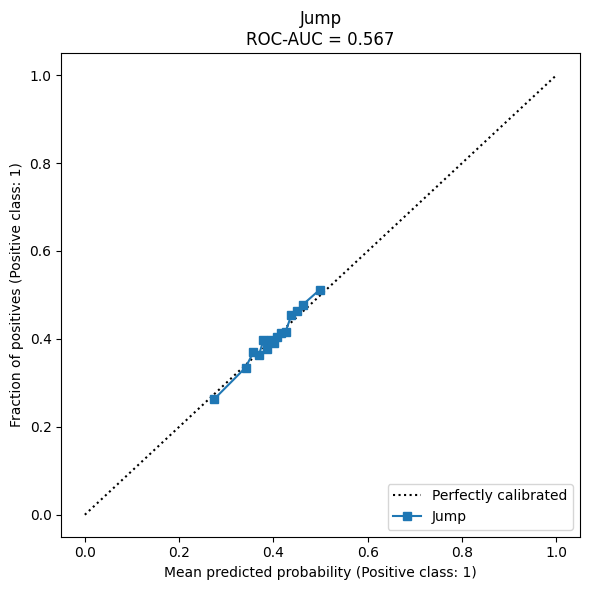

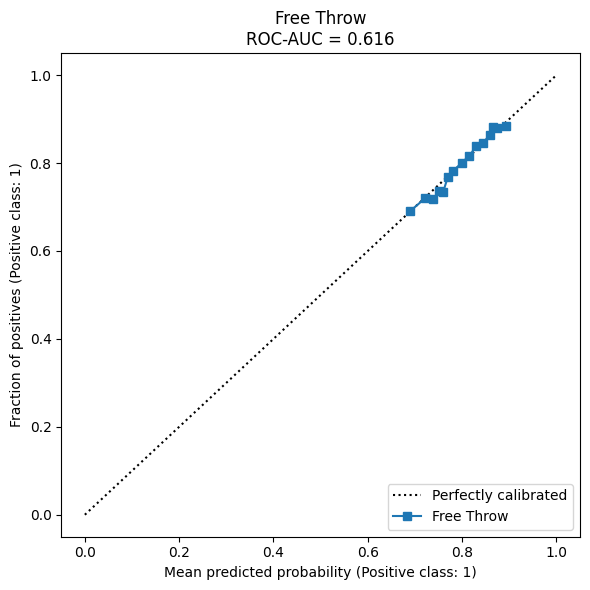

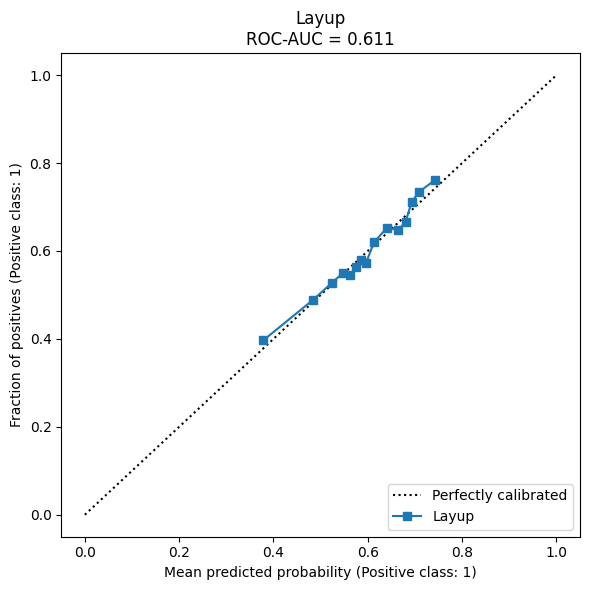

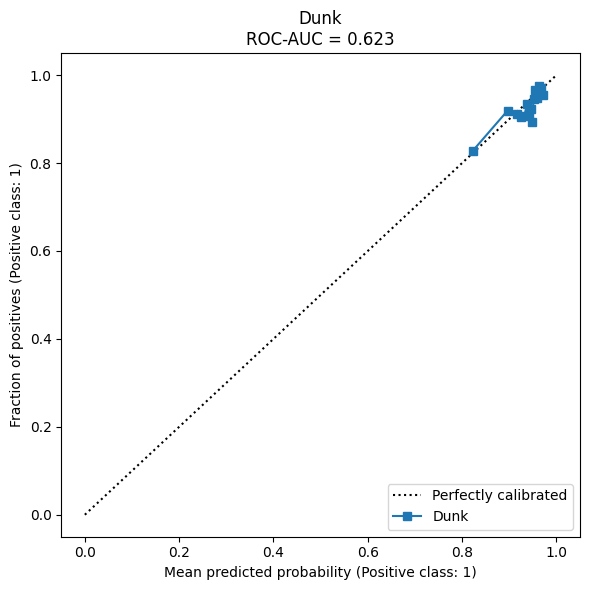

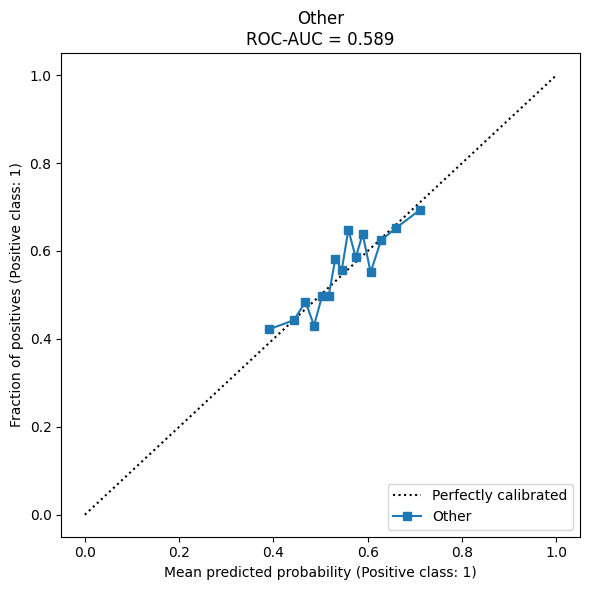

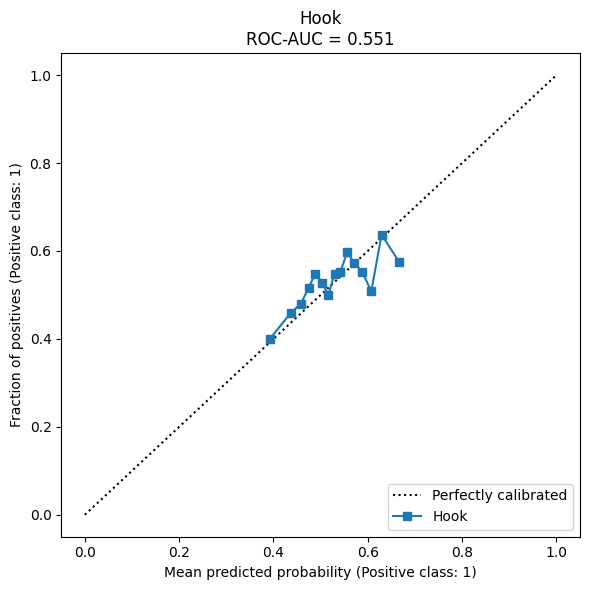

In [26]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    # skip tiny groups
    if len(subset) < 100:
        continue

    y_true_sub = subset["y_true"]
    y_proba_sub = subset["y_pred_proba"]

    auc = roc_auc_score(
        y_true_sub,
        y_proba_sub
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    CalibrationDisplay.from_predictions(
        y_true_sub,
        y_proba_sub,
        n_bins=15,
        strategy="quantile",
        name=action_type,
        ax=ax
    )

    ax.set_title(
        f"{action_type}\n"
        f"ROC-AUC = {auc:.3f}"
    )

    plt.tight_layout()
    plt.show()

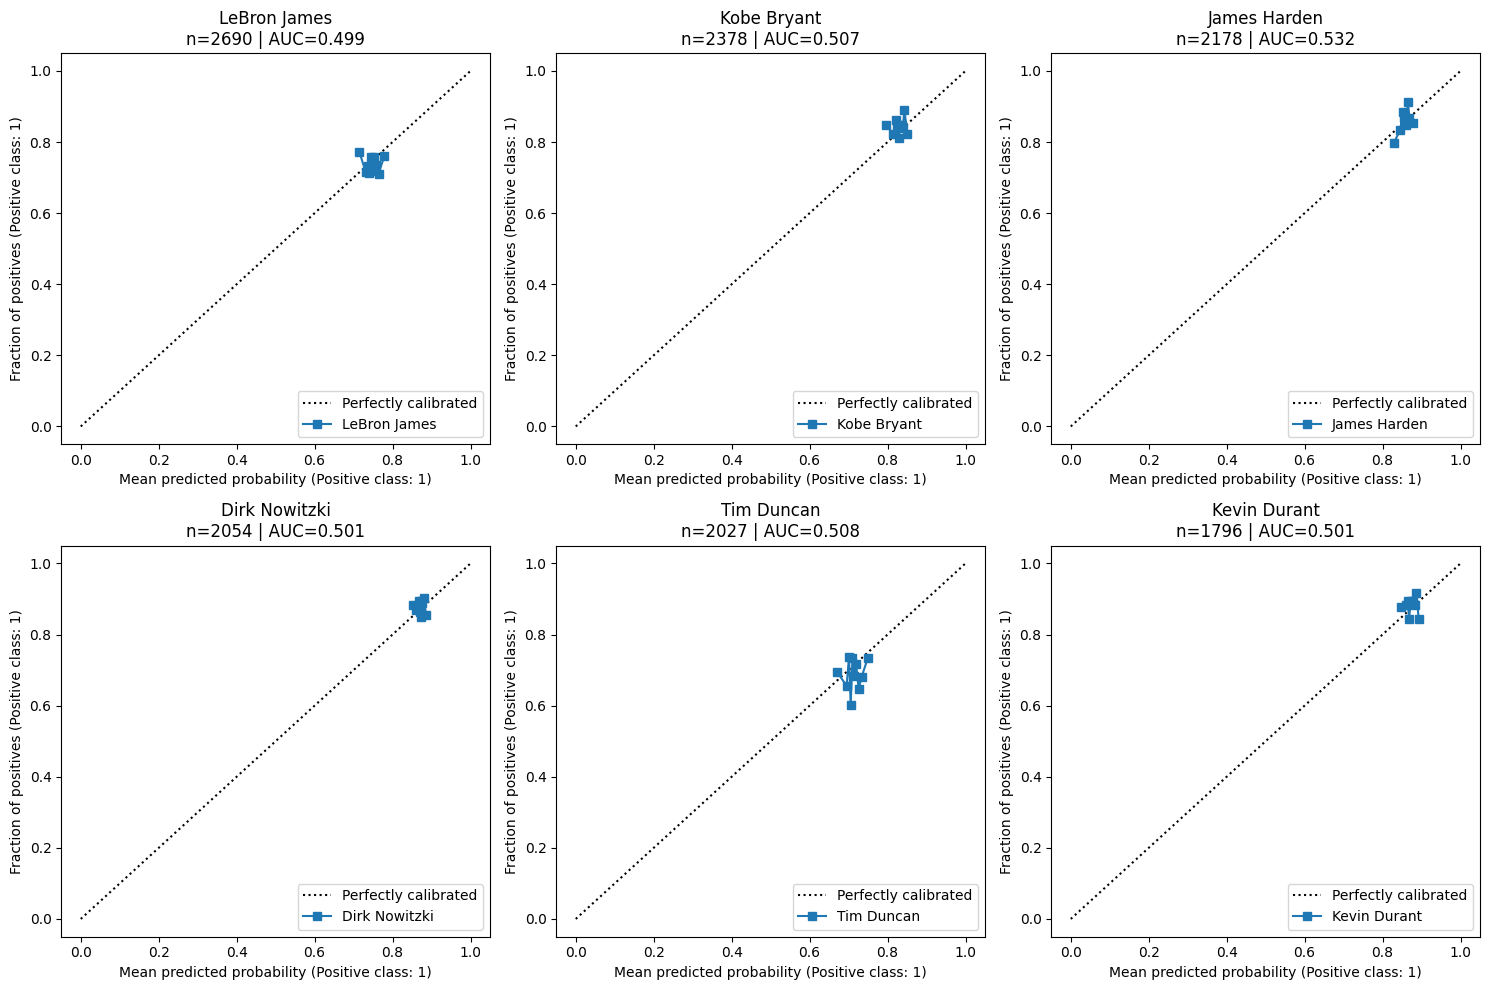

In [30]:
shot_type = "Free Throw"

subset_all = error_df[
    error_df["MAIN_ACTION_TYPE"] == shot_type
]

# top players by sample count
top_players = (
    subset_all["PLAYER_NAME"]
    .value_counts()
    .head(6)
    .index
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, player in zip(axes, top_players):

    subset = subset_all[
        subset_all["PLAYER_NAME"] == player
    ]

    # skip tiny samples
    if len(subset) < 100:
        continue

    y_true_sub = subset["y_true"]
    y_proba_sub = subset["y_pred_proba"]

    auc = roc_auc_score(
        y_true_sub,
        y_proba_sub
    )

    CalibrationDisplay.from_predictions(
        y_true_sub,
        y_proba_sub,
        n_bins=10,
        strategy="quantile",
        name=player,
        ax=ax
    )

    ax.set_title(
        f"{player}\n"
        f"n={len(subset)} | AUC={auc:.3f}"
    )

plt.tight_layout()
plt.show()

## Conclusion for model per shot type

Tried:
- Simple training per shot type
- Training per shot type with weighted samples, to account for imbalanced target distribution
    - To account for imbalance in hit rate for different shot types (e.g. free throws have about 75-80% hits)
- Training per shot type with random upsampling, to have balanced target distribution

Results:
- Even training a model per shot type does not improve the model performance
- The model is either only predicting based on shot type, or performing really bad (mostly guessing)
    - For almost all tests it's only predicting based on shot type
    - For random upsampling it's just guessing
- It seems like with the current feature set, it is not possible to make a reliable/meaningful prediction

### Possible next steps:
- Features for defender information:
    - Distance, defending pressure, ... --> __No Information in the data__
- Player rolling shooting ability:
    - Rolling FG% in last games
    - rolling shot type specific FG%
    - season form
    - game form (FG% in game, FG attempts in game, time played)   --> __Possible but questionable, if this fixes the issue__
- Check for additional datasets